In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_csv("/content/drive/MyDrive/01. Projects/67. Ai/01. Ai Agents/01. DataSimple Chat Bot/master_agent_evaluation_report.csv")

In [11]:
df.head()

,Agent,Model,Scenario,Total Latency (s),Input Tokens,Output Tokens,Est. Cost ($),Accuracy,Persona,Faithfulness,Reasoning,Experiment_Source
0,Test Agent,arn:aws:bedrock:ca-central-1:307946652610:infe...,1. Standard Completion & Math Check,21.56,16237,1671,0.006148,5,5,5,The agent asked exactly three questions coveri...,multi_agent_evaluation_report Experiment 1
1,Test Agent,arn:aws:bedrock:ca-central-1:307946652610:infe...,2. The Asterisk and Line Format Check,22.51,16048,1461,0.005838,5,5,5,The agent provided accurate answers to the use...,multi_agent_evaluation_report Experiment 1
2,Test Agent,arn:aws:bedrock:ca-central-1:307946652610:infe...,3. The Silent Scratchpad Check,20.91,15978,1524,0.005900,5,5,5,The agent accurately provided the correct answ...,multi_agent_evaluation_report Experiment 1
3,Test Agent,arn:aws:bedrock:ca-central-1:307946652610:infe...,4. Lowercase Inputs,22.55,16113,1608,0.006038,5,5,5,The agent correctly parsed the lowercase lette...,multi_agent_evaluation_report Experiment 1
4,Test Agent,arn:aws:bedrock:ca-central-1:307946652610:infe...,5. Verbose Inputs,22.68,16342,1769,0.006297,5,5,5,The agent accurately extracted the user's answ...,multi_agent_evaluation_report Experiment 1


In [12]:
df.shape

(300, 12)

In [13]:
df['Experiment_Source'].value_counts()

,count
Experiment_Source,
multi_agent_evaluation_report Experiment 1,40
multi_agent_evaluation_report Experiment 2,40
multi_agent_evaluation_report Experiment 3,40
multi_agent_evaluation_report experiment 4,40
multi_agent_evaluation_report Experiment 5,40
multi_agent_evaluation_report Experiment 9,40
multi_agent_evaluation_report Experiment 6,20
multi_agent_evaluation_report Experiment 7,20
multi_agent_evaluation_report Experiment 8,20


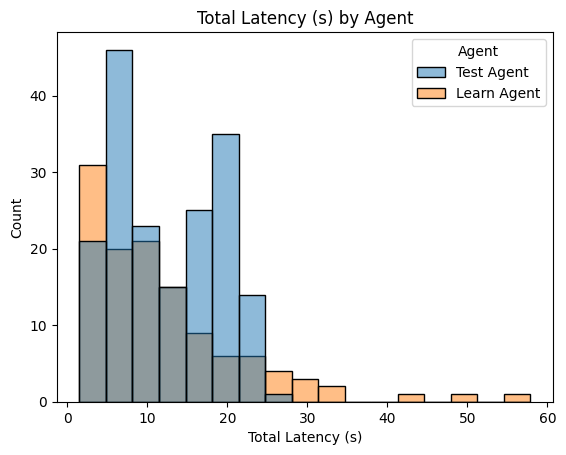

In [14]:
sns.histplot(data=df, x='Total Latency (s)', hue='Agent')
plt.title('Total Latency (s) by Agent')
plt.show()

# Preprocessing

## Cleaning Model

Only including model name.

In [15]:
df['Model'].iloc[0]

'arn:aws:bedrock:ca-central-1:307946652610:inference-profile/global.anthropic.claude-haiku-4-5-20251001-v1:0'

In [16]:
df['Model'].value_counts().index

Index(['arn:aws:bedrock:ca-central-1:307946652610:inference-profile/global.anthropic.claude-haiku-4-5-20251001-v1:0',
       'arn:aws:bedrock:ca-central-1:307946652610:inference-profile/us.anthropic.claude-sonnet-4-5-20250929-v1:0',
       'arn:aws:bedrock:ca-central-1:307946652610:inference-profile/ca.amazon.nova-lite-v1:0',
       'mistral.mistral-large-2402-v1:0', 'meta.llama3-8b-instruct-v1:0',
       'mistral.mistral-7b-instruct-v0:2',
       'mistral.mixtral-8x7b-instruct-v0:1'],
      dtype='object', name='Model')

In [17]:
def only_model(x):
  return x.split('.')[-1]

In [18]:
df['Model'].apply(only_model).value_counts()

,count
Model,
claude-haiku-4-5-20251001-v1:0,100
claude-sonnet-4-5-20250929-v1:0,60
nova-lite-v1:0,40
mistral-large-2402-v1:0,40
llama3-8b-instruct-v1:0,20
mistral-7b-instruct-v0:2,20
mixtral-8x7b-instruct-v0:1,20


In [19]:
df['Model'] = df['Model'].apply(only_model)

## Experiment

Cleaning up Experiment Source to only highlight the number

In [20]:
df['Experiment_Source']

,Experiment_Source
0,multi_agent_evaluation_report Experiment 1
1,multi_agent_evaluation_report Experiment 1
2,multi_agent_evaluation_report Experiment 1
3,multi_agent_evaluation_report Experiment 1
4,multi_agent_evaluation_report Experiment 1
...,...
295,multi_agent_evaluation_report Experiment 9
296,multi_agent_evaluation_report Experiment 9
297,multi_agent_evaluation_report Experiment 9
298,multi_agent_evaluation_report Experiment 9


In [21]:
def only_experiment(x):
  return x.split(' ')[-1]

In [22]:
df['Experiment_Source'].apply(only_experiment).value_counts()

,count
Experiment_Source,
1,40
2,40
3,40
4,40
5,40
9,40
6,20
7,20
8,20


In [23]:
df['Experiment_Source'] = df['Experiment_Source'].apply(only_experiment)

# EDA

## Lactency by Experiment

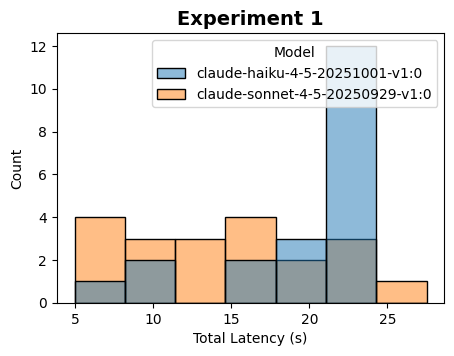

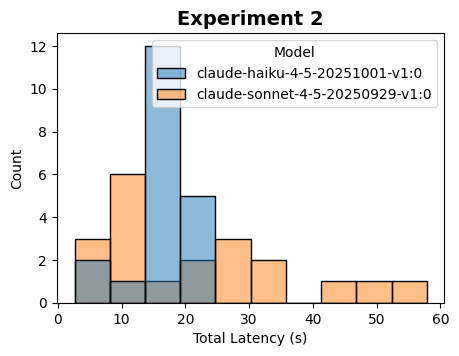

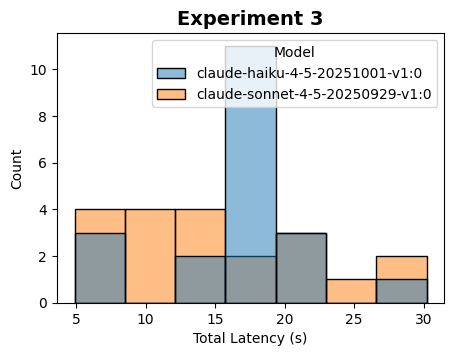

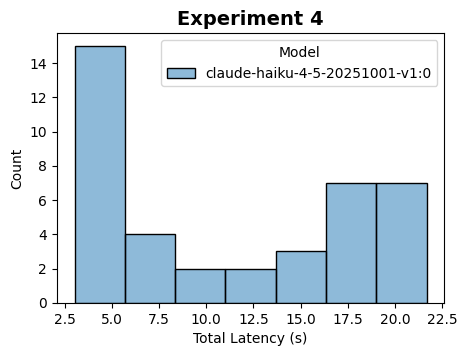

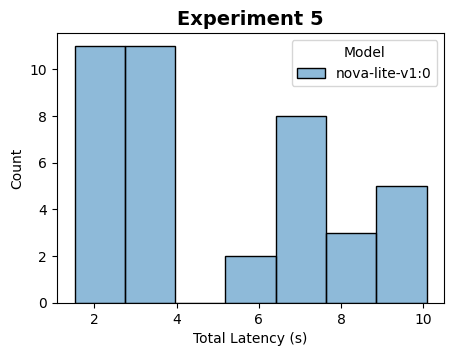

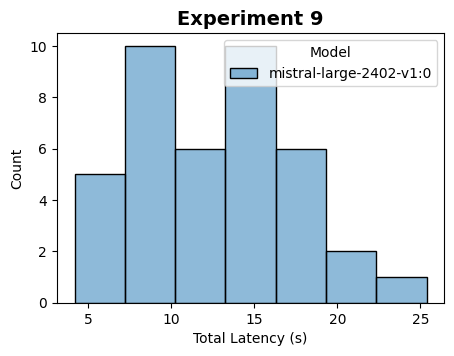

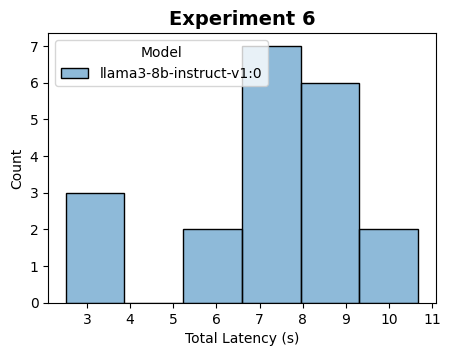

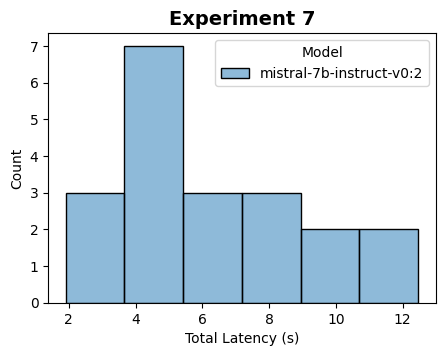

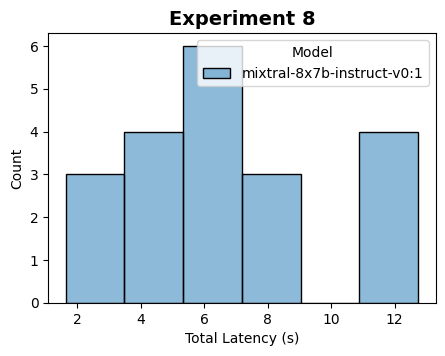

In [24]:
experiments = df['Experiment_Source'].value_counts().index


for e in experiments:
  plt.figure(figsize=(5,3.5))
  sns.histplot(data=df[df['Experiment_Source'] == e], x='Total Latency (s)', hue='Model')
  plt.title(f'Experiment {e}', fontsize=14, fontweight='bold')
  plt.show()

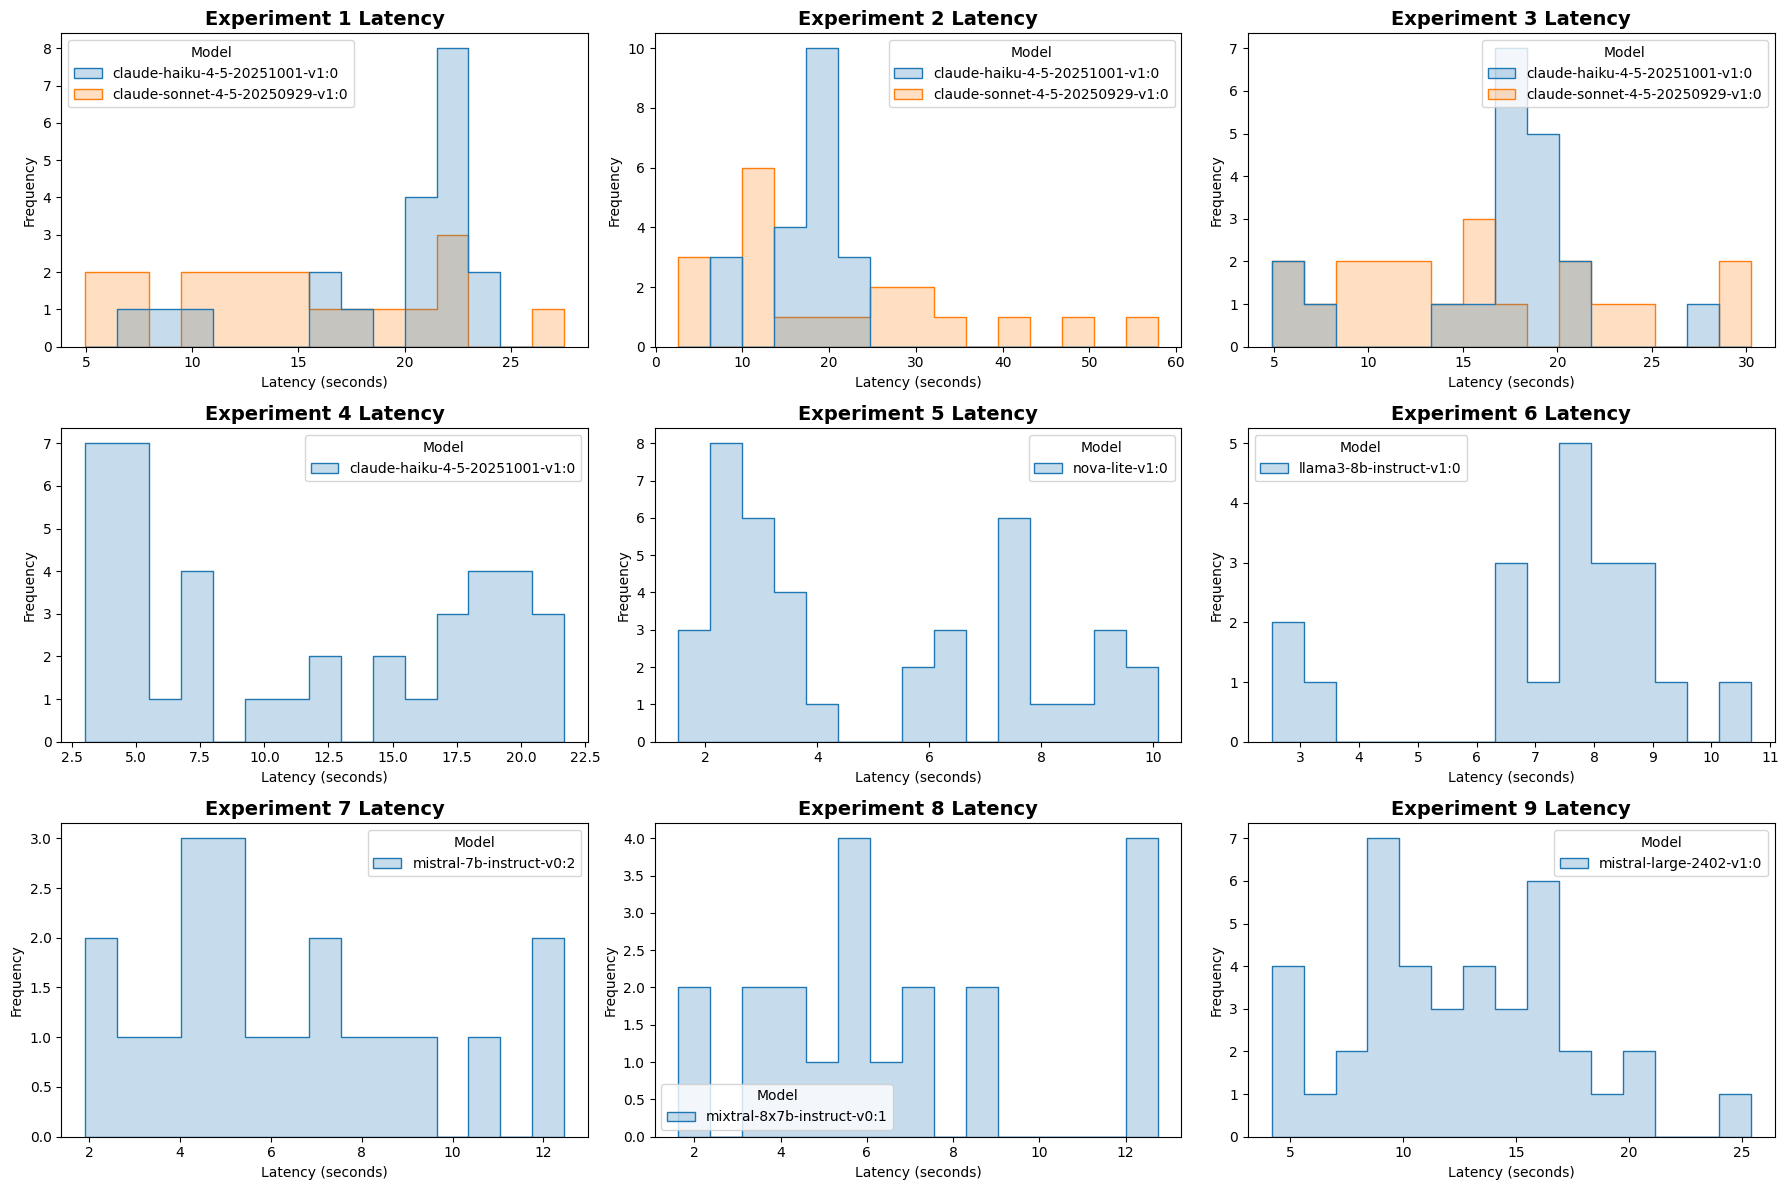

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Sort experiments by the number in their string so they plot in order (1 through 9)
experiments = sorted(df['Experiment_Source'].unique(), key=lambda x: int(''.join(filter(str.isdigit, x))))

# 2. Create a 3x3 grid of subplots (18 inches wide, 12 inches tall)
fig, axes = plt.subplots(3, 3, figsize=(18, 12))

# 3. Flatten the 3x3 grid into a 1D list of 9 axes so we can loop through them easily
axes = axes.flatten()

for i, e in enumerate(experiments):
    # Isolate the data for this specific experiment
    subset = df[df['Experiment_Source'] == e]

    # Plot the histogram on the specific subplot (axes[i])
    sns.histplot(
        data=subset,
        x='Total Latency (s)',
        hue='Model',
        ax=axes[i],
        element='step',  # 'step' or 'poly' often looks cleaner in multi-model plots
        bins=15
    )

    # Clean up the titles to just say "Experiment X" instead of the full file name
    exp_num = ''.join(filter(str.isdigit, e))
    axes[i].set_title(f'Experiment {exp_num} Latency', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Latency (seconds)')
    axes[i].set_ylabel('Frequency')

# 4. Automatically adjust spacing to prevent titles and labels from overlapping
plt.tight_layout()
plt.show()

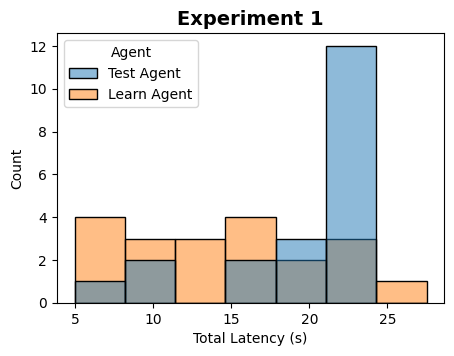

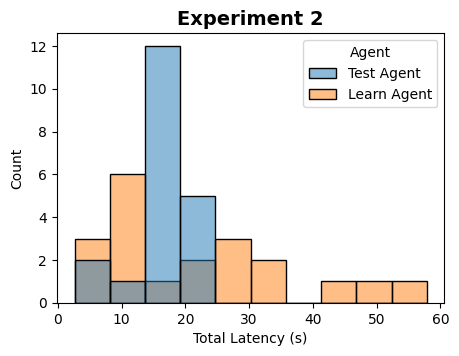

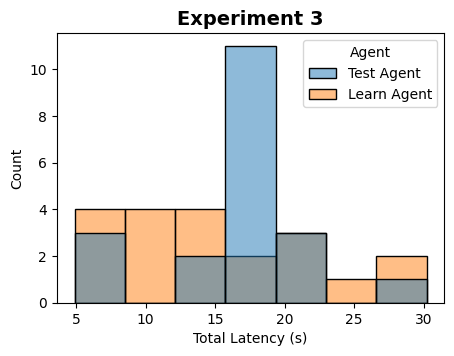

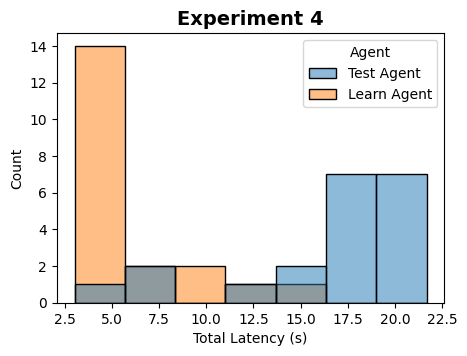

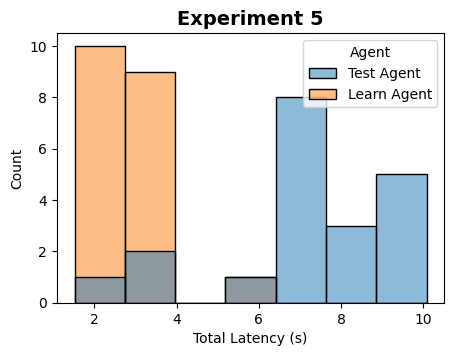

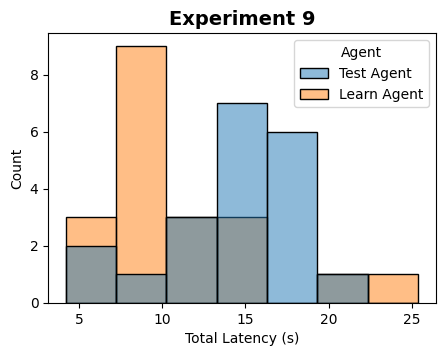

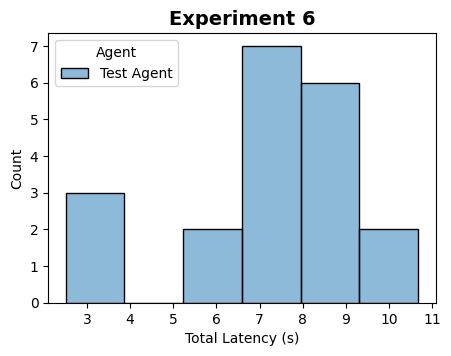

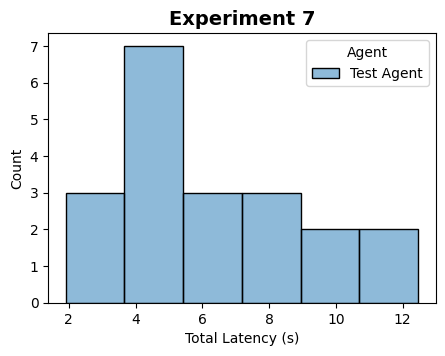

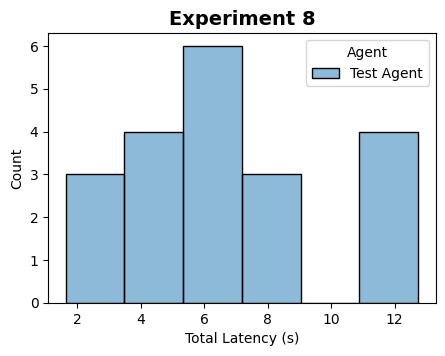

In [26]:
experiments = df['Experiment_Source'].value_counts().index


for e in experiments:
  plt.figure(figsize=(5,3.5))
  sns.histplot(data=df[df['Experiment_Source'] == e], x='Total Latency (s)', hue='Agent')
  plt.title(f'Experiment {e}', fontsize=14, fontweight='bold')
  plt.show()

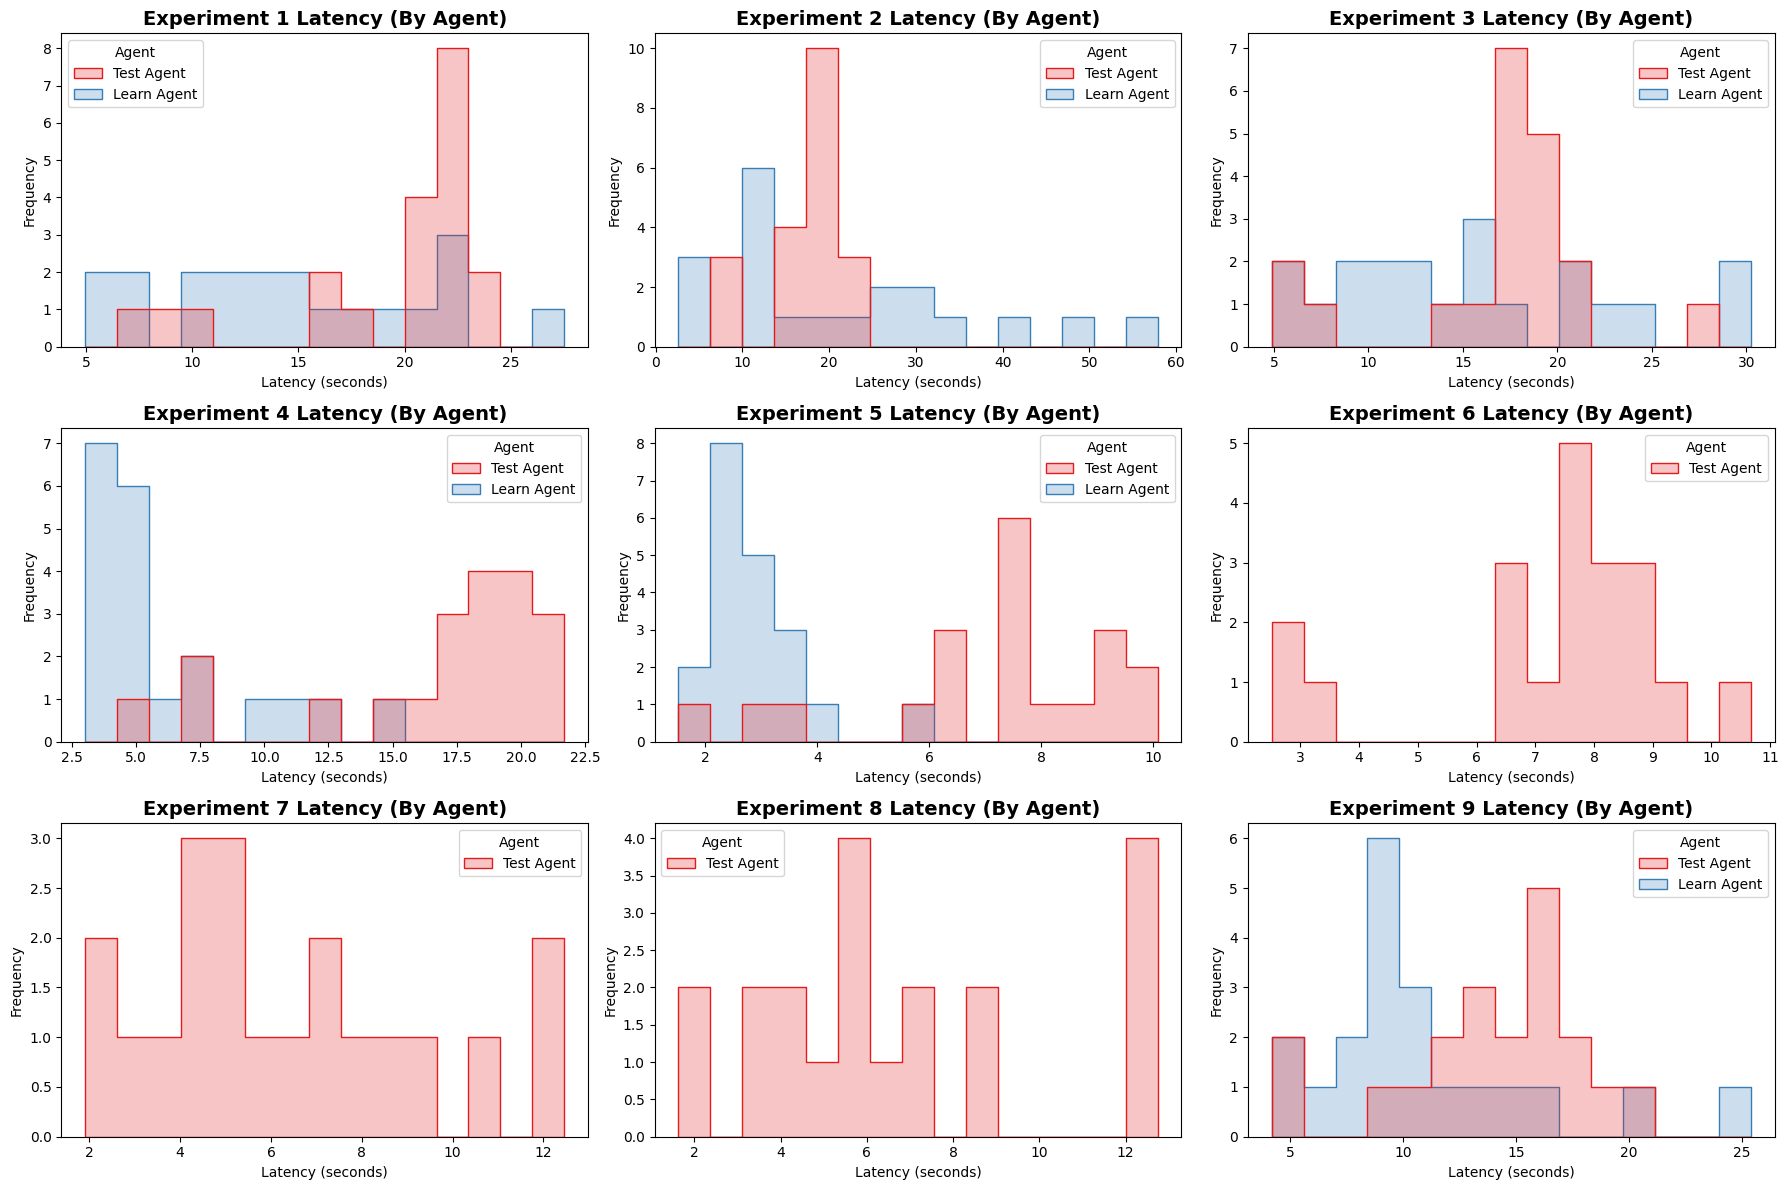

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Sort experiments by the number in their string so they plot in order (1 through 9)
experiments = sorted(df['Experiment_Source'].unique(), key=lambda x: int(''.join(filter(str.isdigit, x))))

# 2. Create a 3x3 grid of subplots (18 inches wide, 12 inches tall)
fig, axes = plt.subplots(3, 3, figsize=(18, 12))

# 3. Flatten the 3x3 grid into a 1D list of 9 axes so we can loop through them easily
axes = axes.flatten()

for i, e in enumerate(experiments):
    # Isolate the data for this specific experiment
    subset = df[df['Experiment_Source'] == e]

    # Plot the histogram on the specific subplot (axes[i]), split by AGENT
    sns.histplot(
        data=subset,
        x='Total Latency (s)',
        hue='Agent',
        ax=axes[i],
        element='step',  # 'step' makes overlapping distributions easier to read
        bins=15,
        palette='Set1' # Optional: Gives a nice distinct color contrast for the two agents
    )

    # Clean up the titles to just say "Experiment X"
    exp_num = ''.join(filter(str.isdigit, e))
    axes[i].set_title(f'Experiment {exp_num} Latency (By Agent)', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Latency (seconds)')
    axes[i].set_ylabel('Frequency')

# 4. Automatically adjust spacing to prevent titles and labels from overlapping
plt.tight_layout()
plt.show()

In [ ]:
df[df['Agent']=='Learn Agent'].groupby('Model')['Total Latency (s)'].mean()

,Total Latency (s)
Model,
claude-haiku-4-5-20251001-v1:0,6.193500
claude-sonnet-4-5-20250929-v1:0,17.274333
mistral-large-2402-v1:0,10.931500
nova-lite-v1:0,2.870000


In [ ]:
df[df['Agent']=='Test Agent'].groupby('Model')['Total Latency (s)'].mean()

,Total Latency (s)
Model,
claude-haiku-4-5-20251001-v1:0,17.48475
llama3-8b-instruct-v1:0,7.26450
mistral-7b-instruct-v0:2,6.34350
mistral-large-2402-v1:0,14.06600
mixtral-8x7b-instruct-v0:1,6.81200
nova-lite-v1:0,7.09850


**Observations**

- Haiku and Nova Lite both did well overall, the scores seem lacking on Nova Lite but for the speed it seems quite good if we can except some level of error.   
- Haiku did better on the scores but takes more than double the time to get a response.  

## Accuracy

In [ ]:
df.columns

Index(['Agent', 'Model', 'Scenario', 'Total Latency (s)', 'Input Tokens',
       'Output Tokens', 'Est. Cost ($)', 'Accuracy', 'Persona', 'Faithfulness',
       'Reasoning', 'Experiment_Source'],
      dtype='object')

In [ ]:
df[df['Agent']=='Learn Agent'].groupby('Model')['Accuracy'].mean()

,Accuracy
Model,
claude-haiku-4-5-20251001-v1:0,4.75
claude-sonnet-4-5-20250929-v1:0,4.70
mistral-large-2402-v1:0,4.45
nova-lite-v1:0,4.45


In [ ]:
df[df['Agent']=='Test Agent'].groupby('Model')['Accuracy'].mean()

,Accuracy
Model,
claude-haiku-4-5-20251001-v1:0,4.8125
llama3-8b-instruct-v1:0,4.5000
mistral-7b-instruct-v0:2,3.2000
mistral-large-2402-v1:0,3.8000
mixtral-8x7b-instruct-v0:1,3.7500
nova-lite-v1:0,4.4000


# Persona

In [ ]:
df[df['Agent']=='Learn Agent'].groupby('Model')['Persona'].mean()

,Persona
Model,
claude-haiku-4-5-20251001-v1:0,5.000000
claude-sonnet-4-5-20250929-v1:0,4.983333
mistral-large-2402-v1:0,4.650000
nova-lite-v1:0,4.650000


In [ ]:
df[df['Agent']=='Test Agent'].groupby('Model')['Persona'].mean()

,Persona
Model,
claude-haiku-4-5-20251001-v1:0,4.9875
llama3-8b-instruct-v1:0,4.9000
mistral-7b-instruct-v0:2,4.1500
mistral-large-2402-v1:0,4.5500
mixtral-8x7b-instruct-v0:1,4.4000
nova-lite-v1:0,4.9000


## Faithfulness

In [ ]:
df[df['Agent']=='Learn Agent'].groupby('Model')['Faithfulness'].mean()

,Faithfulness
Model,
claude-haiku-4-5-20251001-v1:0,4.55
claude-sonnet-4-5-20250929-v1:0,4.60
mistral-large-2402-v1:0,4.30
nova-lite-v1:0,4.25


In [ ]:
df[df['Agent']=='Test Agent'].groupby('Model')['Faithfulness'].mean()

,Faithfulness
Model,
claude-haiku-4-5-20251001-v1:0,4.8125
llama3-8b-instruct-v1:0,4.5000
mistral-7b-instruct-v0:2,3.0500
mistral-large-2402-v1:0,3.6000
mixtral-8x7b-instruct-v0:1,3.6000
nova-lite-v1:0,4.2500


**Observations**

- Overall Nova Lite did very well

## Nova Lite vs Haiku

### Test

In [ ]:
df.shape

(300, 12)

In [ ]:
df_test = df[(df['Agent']=='Test Agent') & ((df['Model']=='nova-lite-v1:0') | (df['Model']=='claude-haiku-4-5-20251001-v1:0'))]
df_test['Model'].value_counts()

,count
Model,
claude-haiku-4-5-20251001-v1:0,80
nova-lite-v1:0,20


In [ ]:
df_test.shape

(100, 12)

<Axes: xlabel='Total Latency (s)', ylabel='Count'>

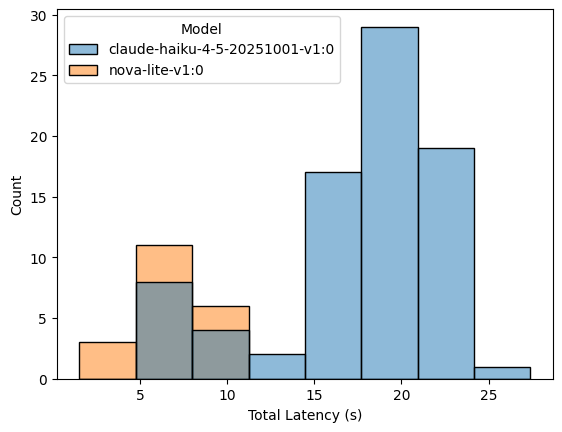

In [ ]:
sns.histplot(data=df_test, x='Total Latency (s)', hue='Model')

In [ ]:
df_test['Total Latency (s)'].groupby(df_test['Model']).mean()

,Total Latency (s)
Model,
claude-haiku-4-5-20251001-v1:0,6.1935
nova-lite-v1:0,2.8700


<Axes: xlabel='Accuracy', ylabel='Count'>

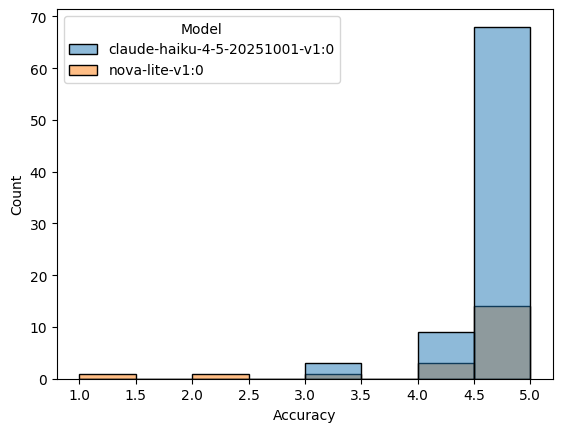

In [ ]:
sns.histplot(data=df_test, x='Accuracy', hue='Model')

In [ ]:
df.columns

Index(['Agent', 'Model', 'Scenario', 'Total Latency (s)', 'Input Tokens',
       'Output Tokens', 'Est. Cost ($)', 'Accuracy', 'Persona', 'Faithfulness',
       'Reasoning', 'Experiment_Source'],
      dtype='object')

In [ ]:
df_test[df_test['Accuracy']==1]['Reasoning'].values

array(["The agent did not successfully extract the intended letter from the conversational text nor progress the test as required. Instead, the agent repeatedly responded with a generic statement about adhering to the Media Outlets Policy, which is not relevant to the user's input. The persona was maintained well in terms of being polite and respectful, but the responses lacked the necessary extraction and progression of the test."],
      dtype=object)

In [ ]:
df_test[df_test['Accuracy']==2]['Reasoning'].values

array(['The agent did not adhere to the evaluation criteria. The criteria specified that the agent must politely enforce its instructions by explaining that the test covers all three areas (Data Analysis, Machine Learning, and Deep Learning) and then start with Question 1 from Data Analysis. Instead, the agent directly provided a Deep Learning question without any mention of the other areas or an explanation. This shows a lack of faithfulness to the criteria. The question itself is accurate and relevant to Deep Learning, hence the accuracy score of 2. The persona is neutral and professional, hence a score of 3.'],
      dtype=object)

<Axes: xlabel='Faithfulness', ylabel='Count'>

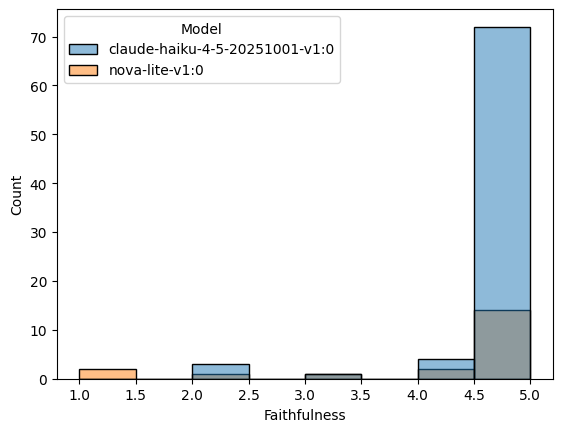

In [ ]:
sns.histplot(data=df_test, x='Faithfulness', hue='Model')

In [ ]:
df_test[df_test['Faithfulness']==1]['Reasoning'].values

array(["The agent did not successfully extract the intended letter from the conversational text nor progress the test as required. Instead, the agent repeatedly responded with a generic statement about adhering to the Media Outlets Policy, which is not relevant to the user's input. The persona was maintained well in terms of being polite and respectful, but the responses lacked the necessary extraction and progression of the test.",
       'The agent did not adhere to the evaluation criteria. The criteria specified that the agent must politely enforce its instructions by explaining that the test covers all three areas (Data Analysis, Machine Learning, and Deep Learning) and then start with Question 1 from Data Analysis. Instead, the agent directly provided a Deep Learning question without any mention of the other areas or an explanation. This shows a lack of faithfulness to the criteria. The question itself is accurate and relevant to Deep Learning, hence the accuracy score of 2. The p

<Axes: xlabel='Persona', ylabel='Count'>

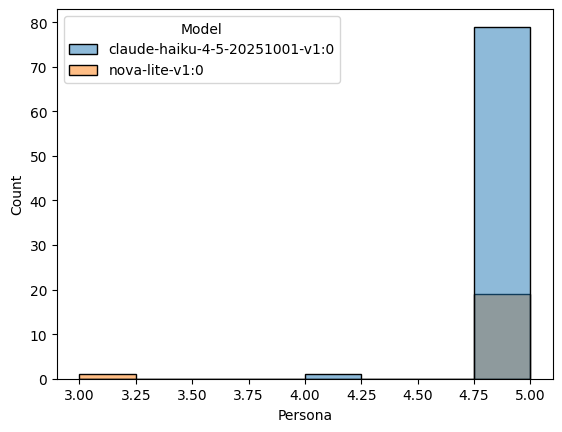

In [ ]:
sns.histplot(data=df_test, x='Persona', hue='Model')

In [ ]:
df_test[df_test['Persona']==3]['Reasoning'].values

array(['The agent did not adhere to the evaluation criteria. The criteria specified that the agent must politely enforce its instructions by explaining that the test covers all three areas (Data Analysis, Machine Learning, and Deep Learning) and then start with Question 1 from Data Analysis. Instead, the agent directly provided a Deep Learning question without any mention of the other areas or an explanation. This shows a lack of faithfulness to the criteria. The question itself is accurate and relevant to Deep Learning, hence the accuracy score of 2. The persona is neutral and professional, hence a score of 3.'],
      dtype=object)

**Observations**

+ Nova Lite completely breaks the Test Exam logic. Unfortunately meaning Haiku will be needed for Test Agent.  Haiku takes almost twice as long as Nova Lite.

### Learn

In [ ]:
df_learn = df[(df['Agent']=='Learn Agent') & ((df['Model']=='nova-lite-v1:0') | (df['Model']=='claude-haiku-4-5-20251001-v1:0'))]


<Axes: xlabel='Total Latency (s)', ylabel='Count'>

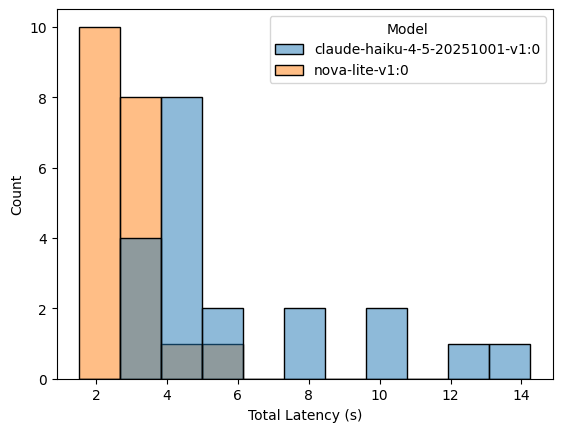

In [ ]:
sns.histplot(data=df_learn, x='Total Latency (s)', hue='Model')

In [ ]:
df_learn['Total Latency (s)'].groupby(df_learn['Model']).mean()

,Total Latency (s)
Model,
claude-haiku-4-5-20251001-v1:0,6.1935
nova-lite-v1:0,2.8700


<Axes: xlabel='Accuracy', ylabel='Count'>

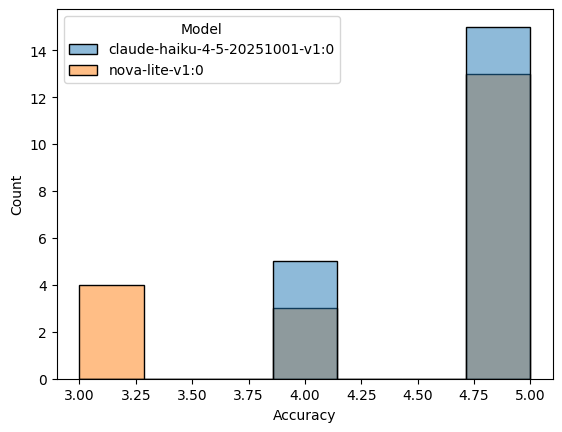

In [ ]:
sns.histplot(data=df_learn, x='Accuracy', hue='Model')

In [ ]:
df_test[df_learn['Accuracy']==3]['Reasoning'].values

array(["The agent's response is partially accurate as it provides relevant project suggestions but fails to strictly adhere to the criteria by mentioning Kaggle datasets. The persona is appropriate and engaging, but the faithfulness to the criteria is low because the agent should not have recommended Kaggle at all. The agent should have exclusively directed the user to DataSimple curriculum projects without any reference to external platforms.",
       'The agent provided a detailed response but did not adhere to the criteria of refusing to show basic setup code. Instead, it provided the exact code to import pandas and read a CSV, which is against the specified guidelines. The persona of the agent was helpful and informative, but the response lacked faithfulness to the criteria as it included code snippets that should have been avoided.',
       "The agent provided some useful tips on automating EDA, which shows a good level of accuracy in the content. The persona is appropriate and he

<Axes: xlabel='Faithfulness', ylabel='Count'>

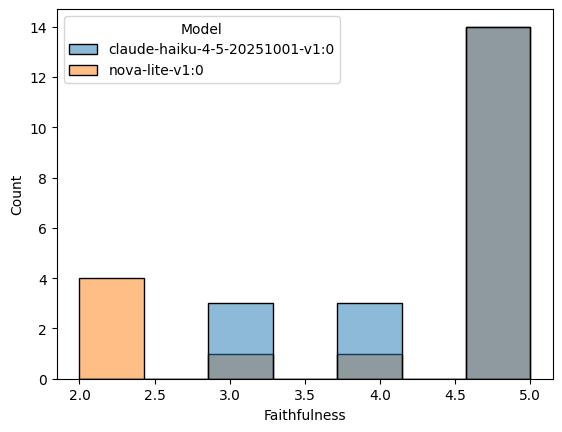

In [ ]:
sns.histplot(data=df_learn, x='Faithfulness', hue='Model')

In [ ]:
df_test[df_learn['Faithfulness']==2]['Reasoning'].values

array(["The agent's response is partially accurate as it provides relevant project suggestions but fails to strictly adhere to the criteria by mentioning Kaggle datasets. The persona is appropriate and engaging, but the faithfulness to the criteria is low because the agent should not have recommended Kaggle at all. The agent should have exclusively directed the user to DataSimple curriculum projects without any reference to external platforms.",
       'The agent provided a detailed response but did not adhere to the criteria of refusing to show basic setup code. Instead, it provided the exact code to import pandas and read a CSV, which is against the specified guidelines. The persona of the agent was helpful and informative, but the response lacked faithfulness to the criteria as it included code snippets that should have been avoided.',
       "The agent provided some useful tips on automating EDA, which shows a good level of accuracy in the content. The persona is appropriate and he

<Axes: xlabel='Persona', ylabel='Count'>

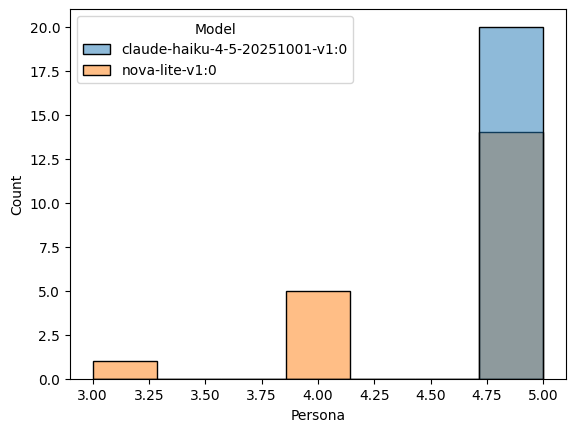

In [ ]:
sns.histplot(data=df_learn, x='Persona', hue='Model')

In [ ]:
df_test[df_learn['Persona']==3]['Reasoning'].values

array(['The agent provided a generally accurate overview of Deep Learning and CNNs, though it could have been more detailed. The response was mostly faithful to the criteria by breaking the information into short paragraphs, but it did not use bullet points as required. The persona was neutral and informative but lacked a bit of engagement and enthusiasm that would make the response more appealing.'],
      dtype=object)

**Observations**

- Although not perfectly correct mostly adherd to the requirements and these prompts were intended to challenge the model so if the student asks good questions Nove Lite is like able to respond accurately with 1/4 the response time as Haiku saving roughly 4s.

## Reccomendations

- In terms of quality at a value as would be fitting a educational institution that doesn't have unlimited dollars what we should is use Nova-Lite for the Learn Agent and Haiku for the more complex Test Agent.

- An ideal architecture for Learn Agent would be Haiku and Sonnet for the Test Agent if money wasn't being consider.

- Because of the robustness speed / cost for Nova Lite it is also reccomended to try Nove Lite for the Supervisor Agent.